# Publication schematic of the microwave-cavity experiment (top view)

Draws the **x-y (top) view** of the 3D cavity simulated in
`20250505 2D SHU Experimental Antennas/20250708_Numerical_Experiment_3D_Cavity/20250708 Numerical Experiment Cavity 3D.ipynb`
and analysed in `20260714 Analysis Focusing Cavity.ipynb`.

It is the publication version of the projection template produced by
`H:\Codes\Nice Experiments\Generate_Projection` (`generate_projection_points.plot_disks`),
which is a *physical* template (black background, white disks with cross-hairs, red
inset) meant to be projected onto the optical table. Here the same $\chi=0.37$ point
pattern is redrawn to scale on a white background with the sources, monitors and
boundary conditions annotated.

**Everything is taken from the simulation, not from the manuscript text** -- see the
`Discrepancies` section at the bottom, the manuscript paragraph disagrees with the
code in three places.

Geometry (simulation units are **cm**; $c = 3\times10^{10}$ cm/s with frequencies in GHz):

| quantity | value |
|---|---|
| cavity $L_x \times L_y \times L_z$ | $110 \times 70 \times 0.5$ cm |
| slab (rods kept) | $\|x\| \le 55a/2$, $\|y\| \le 100a\cdot0.07/2$ = $87.3 \times 11.1$ cm |
| rods | $\varepsilon = 45$, $r = 0.189\,a = 3$ mm, height $0.5$ cm, $N = 382$ |
| characteristic length | $a = 1.5873$ cm $\approx 15.9$ mm |
| emitters | 12 $E_z$ point dipoles, $x = \pm0.5, \pm1.5, \dots, \pm5.5$ cm |
| emitter plane | $y = -100a\cdot0.07/2 - 22.5 = -28.06$ cm |
| synthetic focus | $z_{\rm focus} = 22.5$ cm downstream $\Rightarrow$ the slab entrance face |
| flux monitors | $y = \pm(110\cdot0.07/2 + 3) = \pm6.85$ cm |
| boundaries | absorber (160 layers) in $x,y$; PEC plates in $z$ |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.collections import EllipseCollection

# same house style as the other notebooks in this folder
plt.rc('font', family='Arial', size=12)
plt.rc('pdf', fonttype=42)   # editable text in the PDF (journal requirement)
plt.rc('ps', fonttype=42)

FIGDIR = Path("./figures")
FIGDIR.mkdir(exist_ok=True)

## 1. Geometry parameters

Copied verbatim from the run notebook. `SLICING = 0.07` is the fraction of the
original $100a \times 100a$ SHU box kept along $y$ (the propagation direction), and
`SLAB_SIZE_X = 55` is the kept extent along $x$ **in units of $a$**.

In [2]:
A            = 1.5873          # characteristic length [cm]  (~15.9 mm)
SLICING      = 0.07            # kept fraction of the 100a box along y
SLAB_SIZE_X  = 55              # kept extent along x, in units of a
BOX_A        = 100             # original SHU box side, in units of a

LX, LY       = 110.0, 70.0     # cavity footprint [cm]
AIR_GAP      = 0.0             # air gap above the rods [cm] (0 mm dataset)
LZ           = 0.5 + AIR_GAP   # cavity height [cm]

ROD_R        = 0.189 * A       # rod radius [cm] = 0.3 cm = 3 mm
ROD_H        = 0.5             # rod height [cm]
EPS_ROD      = 45.0
CHI          = 0.37

SLAB_HALF_X  = SLAB_SIZE_X / 2 * A          # 43.65 cm
SLAB_HALF_Y  = BOX_A / 2 * A * SLICING      #  5.556 cm

EMITTER_X    = np.arange(-5.5, 6.5, 1.0)    # 12 dipoles, 1 cm apart
EMITTER_Y    = -SLAB_HALF_Y - 22.5          # -28.056 cm
Z_FOCUS      = 22.5                         # emitter plane -> focus [cm]
FOCUS_Y      = EMITTER_Y + Z_FOCUS          # = -SLAB_HALF_Y: the entrance face
W_AP         = 5.5                          # aperture 1/e half-width at the emitters [cm]
W_0          = 2.0                          # waist at the synthetic focus [cm]

FLUX_Y       = LX * SLICING / 2 + 3         # +/- 6.85 cm

print(f"slab      : {2*SLAB_HALF_X:.1f} x {2*SLAB_HALF_Y:.2f} cm"
      f"  ({2*SLAB_HALF_X*10:.0f} x {2*SLAB_HALF_Y*10:.0f} mm)")
print(f"emitters  : y = {EMITTER_Y:.3f} cm, focus at y = {FOCUS_Y:.3f} cm")
print(f"monitors  : y = +/- {FLUX_Y:.2f} cm")

slab      : 87.3 x 11.11 cm  (873 x 111 mm)
emitters  : y = -28.056 cm, focus at y = -5.556 cm
monitors  : y = +/- 6.85 cm


## 2. Load the $\chi = 0.37$ point pattern

Same parser and same cut as the run notebook (first sample of the file). The `.dat`
files ship with the *Generate_Projection* project; the first existing candidate below
is used.

In [3]:
STRUCTURE_DIRS = [
    Path(r"H:\Codes\Nice Experiments\Generate_Projection\2D SHU"),
    Path(r"H:\phd stuff\tidy3d\structures\2D SHU"),
    Path("../../../structures/2D SHU"),
]
SAMPLE_FILE = "chi_0.37_N_10000_posics.dat"


def load_sample(stem=SAMPLE_FILE, sample=0, dirs=STRUCTURE_DIRS):
    """Return the (N, 2) point pattern of sample `sample`, in units of a.

    File layout: line 0 = number of samples, then for each sample a header line
    `Npoints  box_x  box_y` followed by Npoints coordinate lines.
    """
    for d in dirs:
        path = Path(d) / stem
        if path.exists():
            break
    else:
        raise FileNotFoundError(f"{stem} not found in any of {[str(d) for d in dirs]}")

    lines = path.read_text().splitlines()
    index = 1
    for k in range(sample + 1):
        n = int(lines[index].split()[0])
        header, index = lines[index], index + n + 1
        pts = np.array([list(map(float, s.split())) for s in lines[index - n:index]])
    print(f"loaded {path}  (sample {sample}: {pts.shape[0]} points, "
          f"box {float(header.split()[1]):.2f}a)")
    return pts


def slab_centers(pts):
    """Scale by a and apply the same rectangular cut as the run notebook."""
    xy = pts * A
    keep = (np.abs(xy[:, 1]) <= SLAB_HALF_Y) & (np.abs(xy[:, 0]) <= SLAB_HALF_X)
    return xy[keep]


centers = slab_centers(load_sample())
print(f"{len(centers)} rods inside the slab")

loaded H:\Codes\Nice Experiments\Generate_Projection\2D SHU\chi_0.37_N_10000_posics.dat  (sample 0: 10006 points, box 100.03a)
382 rods inside the slab


## 3. The schematic

Single annotated top view. Knobs worth touching:

* `rod_scale` -- rods are drawn **to scale** by default ($r = 3$ mm on a 110 cm
  canvas, i.e. ~3 pt on paper). Set e.g. `rod_scale=1.5` if the printed version
  looks too faint; the caption should then say the rods are enlarged.
* `show_beam` / `show_monitors` / `show_dims` -- turn off any annotation layer.
  `show_sources` follows `show_beam` unless set explicitly (dipoles without the cone).
* `savename=None` -- render without writing files.

Colours are from the Okabe-Ito colour-blind-safe set: blue `#0072B2` (structure),
vermillion `#D55E00` (sources/beam), bluish green `#009E73` (monitors).

saved figures\cavity_schematic.pdf


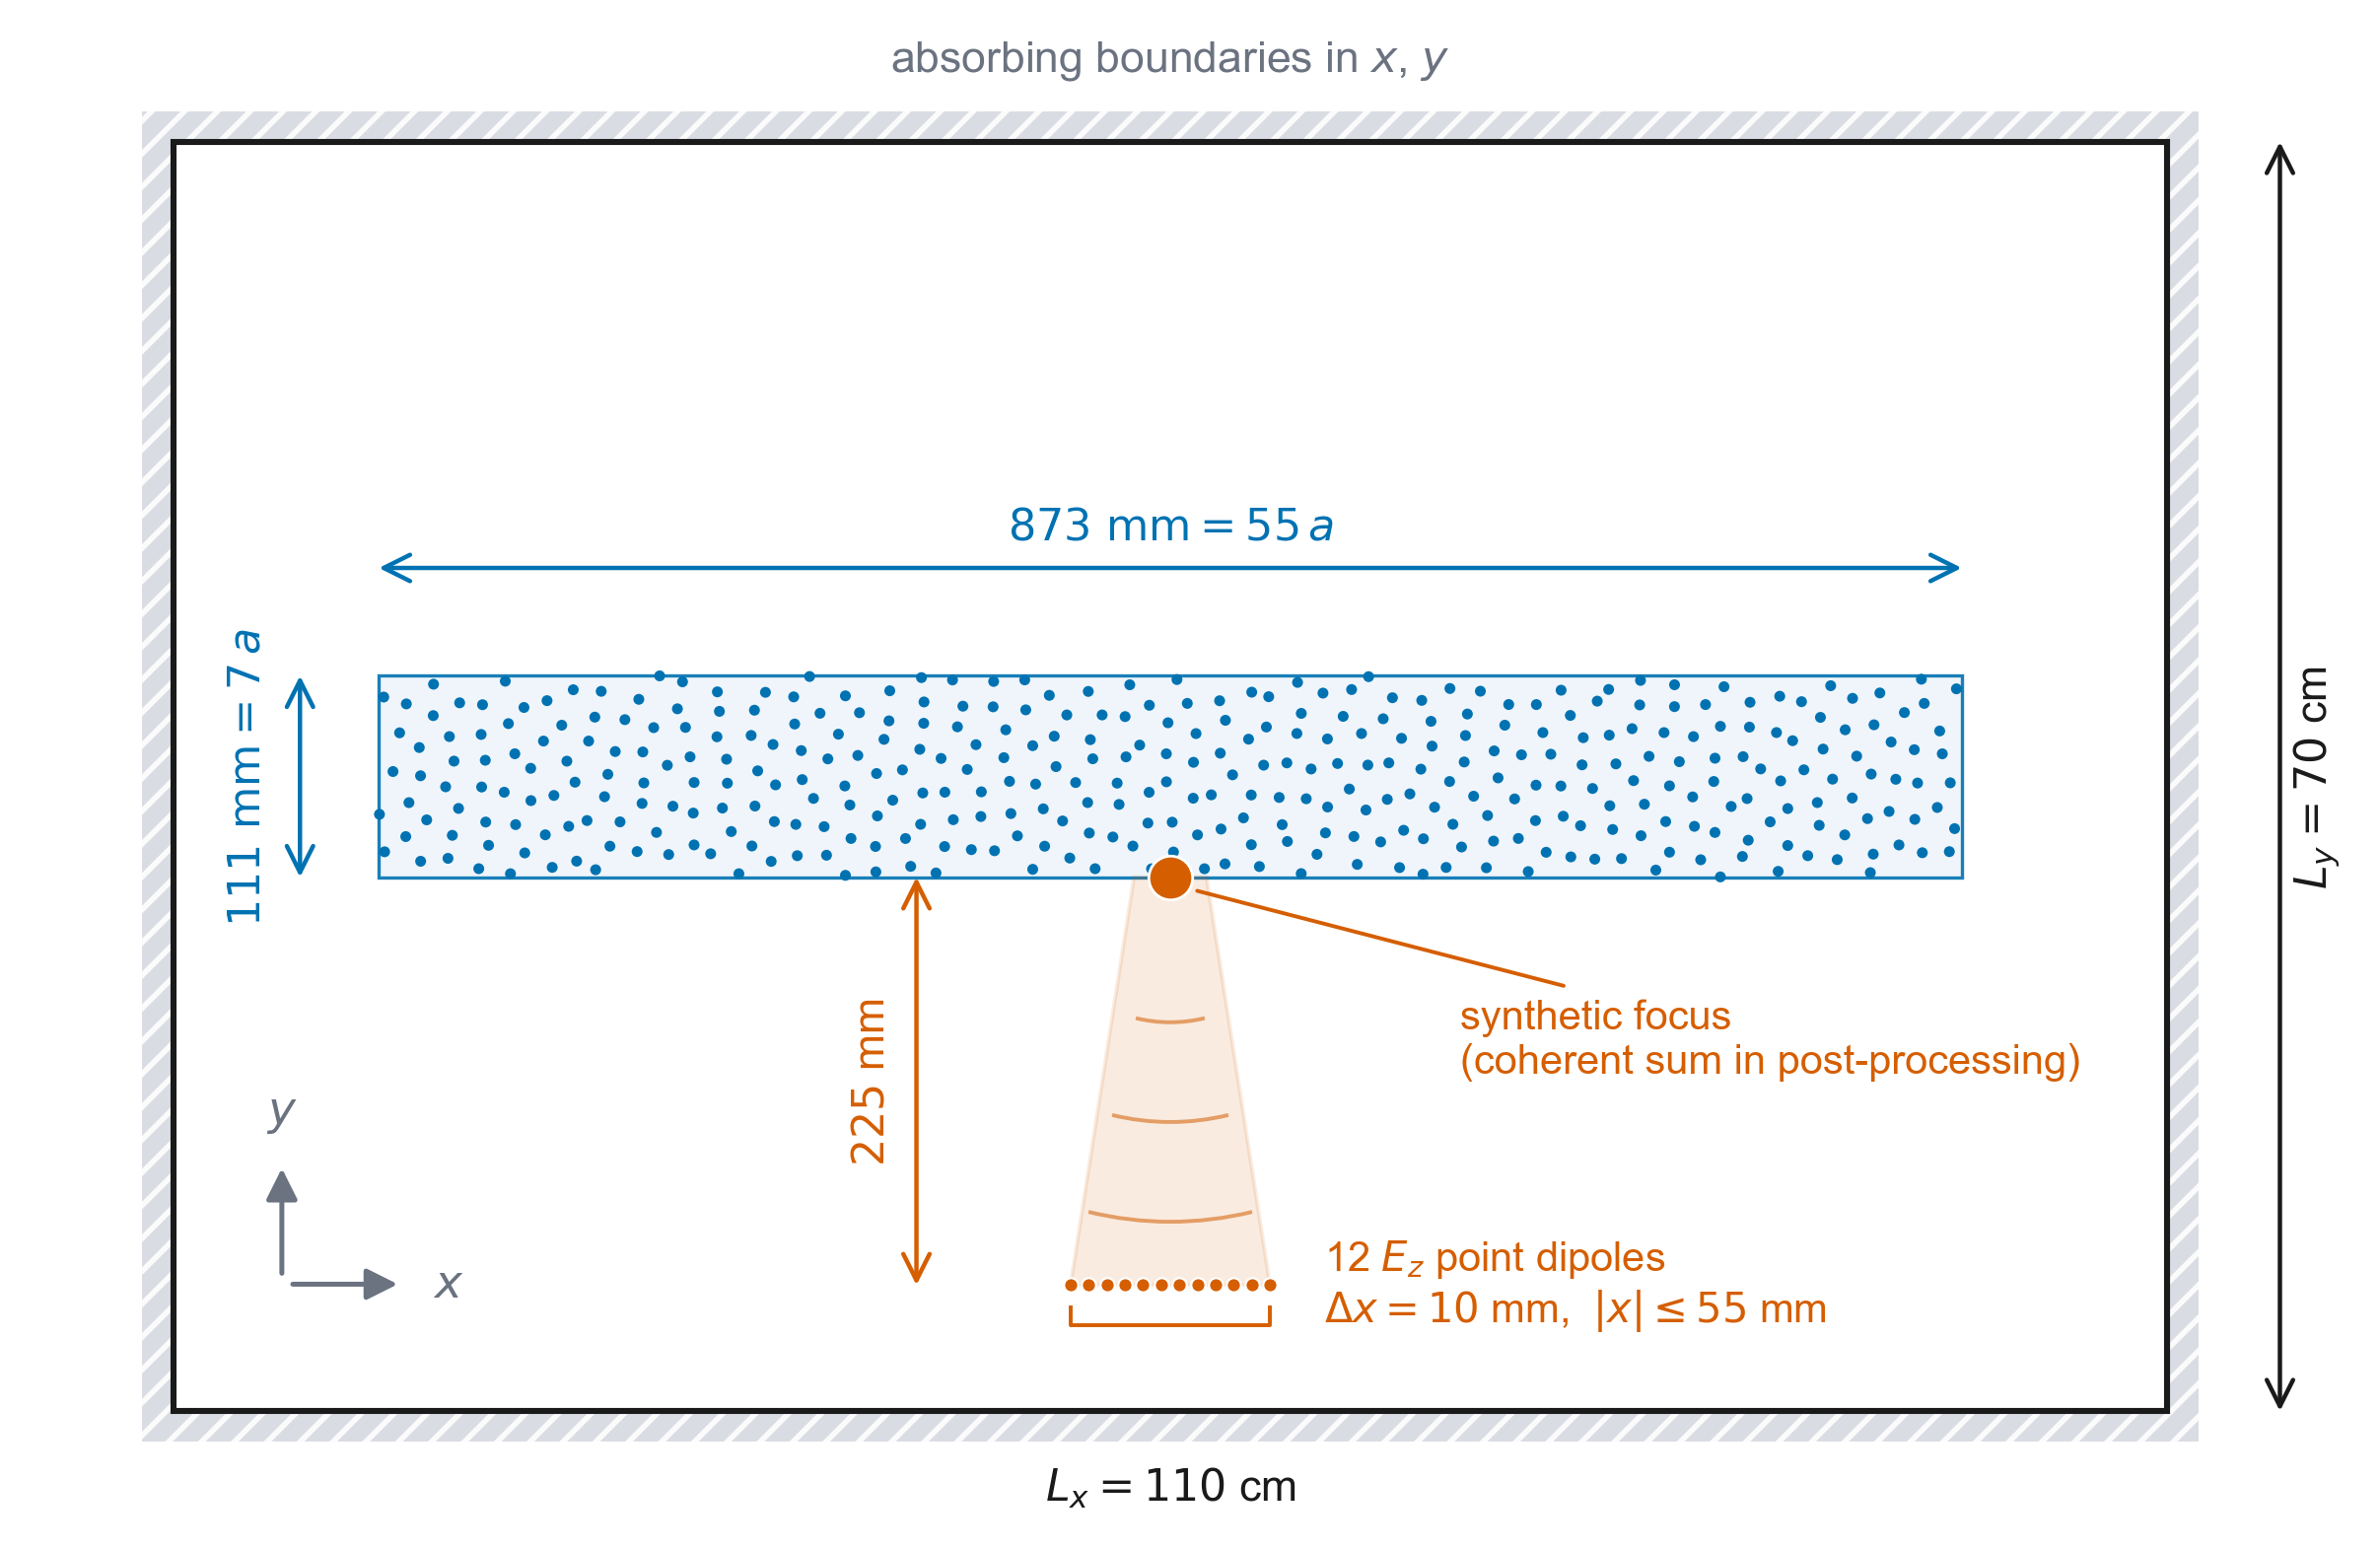

In [6]:
C_ROD     = "#0072B2"
C_SRC     = "#D55E00"
C_MON     = "#009E73"
C_INK     = "#1a1a1a"
C_MUTED   = "#6b7280"
C_ABS     = "#d9dde3"


def _dim(ax, p0, p1, label, offset=(0, 0), rotation=0, fs=8, color=C_INK, pad=0.0):
    """Double-headed dimension arrow from p0 to p1 with a label at its midpoint."""
    ax.annotate("", xy=p1, xytext=p0,
                arrowprops=dict(arrowstyle="<->", lw=0.8, color=color,
                                shrinkA=pad, shrinkB=pad))
    mx, my = (p0[0] + p1[0]) / 2 + offset[0], (p0[1] + p1[1]) / 2 + offset[1]
    ax.text(mx, my, label, fontsize=fs, color=color, rotation=rotation,
            ha="center", va="center", rotation_mode="anchor")


def plot_cavity_schematic(centers, rod_scale=1.0, show_beam=True, show_monitors=True,
                          show_dims=True, show_sources=None, show_params=False, 
                          savename="cavity_schematic",
                          figsize=(7.4, 5.2), dpi=400):
    if show_sources is None:          # sources follow the beam layer unless asked otherwise
        show_sources = show_beam
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_aspect("equal")
    ax.set_axis_off()

    # ---- absorbing frame (tidy3d puts the absorber layers OUTSIDE the domain) ----
    t = 1.7                                                   # drawn thickness [cm]
    frame = patches.Rectangle((-LX/2 - t, -LY/2 - t), LX + 2*t, LY + 2*t,
                              facecolor=C_ABS, edgecolor="none", zorder=0)
    ax.add_patch(frame)
    ax.add_patch(patches.Rectangle((-LX/2 - t, -LY/2 - t), LX + 2*t, LY + 2*t,
                                   facecolor="none", edgecolor="white", lw=0.0,
                                   hatch="////", zorder=0.1, alpha=0.9))
    # ---- cavity domain ----
    ax.add_patch(patches.Rectangle((-LX/2, -LY/2), LX, LY, facecolor="white",
                                   edgecolor=C_INK, lw=1.1, zorder=1))
    ax.text(0, LY/2 + t + 1.6, "absorbing boundaries in $x$, $y$",
            fontsize=8, color=C_MUTED, ha="center", va="bottom")

    # ---- slab + rods ----
    ax.add_patch(patches.Rectangle((-SLAB_HALF_X, -SLAB_HALF_Y),
                                   2*SLAB_HALF_X, 2*SLAB_HALF_Y,
                                   facecolor="#eef4fb", edgecolor=C_ROD,
                                   lw=0.6, alpha=0.9, zorder=2))
    d = 2 * ROD_R * rod_scale
    ax.add_collection(EllipseCollection(np.full(len(centers), d), np.full(len(centers), d),
                                        np.zeros(len(centers)), units="x",
                                        offsets=centers, offset_transform=ax.transData,
                                        facecolors=C_ROD, edgecolors="none", zorder=3))

    # ---- monitors ----
    if show_monitors:
        for sgn, name in ((-1, "entrance"), (+1, "exit")):
            ax.plot([-LX/2, LX/2], [sgn*FLUX_Y]*2, ls=(0, (5, 3)), lw=1.0,
                    color=C_MON, zorder=4)
        ax.text(LX/2 - 1.5, FLUX_Y + 1.0, "flux monitor (exit)", fontsize=7.5,
                color=C_MON, ha="right", va="bottom")
        ax.text(LX/2 - 1.5, -FLUX_Y - 1.0, "flux monitor (entrance)", fontsize=7.5,
                color=C_MON, ha="right", va="top")
        ax.text(-LX/2 + 1.5, LY/2 - 2.0,
                r"$E_z$ recorded on the full $x$-$y$ plane",
                fontsize=7.5, color=C_MON, ha="left", va="top")

    # ---- synthesised converging beam ----
    if show_beam:
        cone = np.array([[-W_AP, EMITTER_Y], [-W_0, FOCUS_Y],
                         [ W_0, FOCUS_Y], [ W_AP, EMITTER_Y]])
        ax.add_patch(patches.Polygon(cone, closed=True, facecolor=C_SRC, alpha=0.12,
                                     edgecolor=C_SRC, lw=0.7, zorder=3.5))
        # a few converging wavefronts, centred on the focus
        th = np.degrees(np.arctan2(W_AP, Z_FOCUS))
        for R in (8.0, 13.5, 19.0):
            ax.add_patch(patches.Arc((0, FOCUS_Y), 2*R, 2*R, angle=0,
                                     theta1=270 - th, theta2=270 + th,
                                     lw=0.7, color=C_SRC, alpha=0.55, zorder=3.4))
        ax.plot([0], [FOCUS_Y], marker="o", ms=8, color=C_SRC,
                mec="white", mew=0.5, zorder=6)
        ax.annotate("synthetic focus\n(coherent sum in post-processing)",
                    xy=(0.9, FOCUS_Y - 0.6), xytext=(16.0, -14.5),
                    fontsize=7.5, color=C_SRC, ha="left", va="center",
                    arrowprops=dict(arrowstyle="-", lw=0.7, color=C_SRC,
                                    shrinkA=1, shrinkB=2))

    # ---- emitters ----
    if show_sources:
        ax.plot(EMITTER_X, np.full_like(EMITTER_X, EMITTER_Y), ls="none", marker="o",
                ms=2.6, mfc=C_SRC, mec="white", mew=0.4, zorder=6)
        ax.text(W_AP + 3.0, EMITTER_Y,
                f"{len(EMITTER_X)} $E_z$ point dipoles\n"
                r"$\Delta x = 10$ mm,  $|x| \leq 55$ mm",
                fontsize=7.5, color=C_SRC, ha="left", va="center")

    # ---- dimensions ----
    if show_dims:
        _dim(ax, (-LX/2, -LY/2 - t - 4.5), (LX/2, -LY/2 - t - 4.5),
             r"$L_x = 110$ cm", offset=(0, 2.0))
        _dim(ax, (LX/2 + t + 4.5, -LY/2), (LX/2 + t + 4.5, LY/2),
             r"$L_y = 70$ cm", offset=(2.0, 0), rotation=90)
        _dim(ax, (-SLAB_HALF_X, 11.5), (SLAB_HALF_X, 11.5),
             r"$873\ \mathrm{mm} = 55\,a$", offset=(0, 2.2), color=C_ROD)
        _dim(ax, (-48.0, -SLAB_HALF_Y), (-48.0, SLAB_HALF_Y),
             r"$111\ \mathrm{mm} = 7\,a$", offset=(-2.8, 0), rotation=90, color=C_ROD)
        if show_sources:
            _dim(ax, (-14.0, EMITTER_Y), (-14.0, FOCUS_Y),
                 r"$225$ mm", offset=(-2.4, 0), rotation=90, color=C_SRC)
            # emitter-array extent
            ax.plot([-W_AP, -W_AP, W_AP, W_AP],
                    [EMITTER_Y - 1.2, EMITTER_Y - 2.2, EMITTER_Y - 2.2, EMITTER_Y - 1.2],
                    lw=0.7, color=C_SRC, zorder=5)

    # ---- coordinate triad (propagation is +y) ----
    ox, oy, ln = -49.0, -28.0, 7.0
    for dx, dy, lab, lx, ly in ((ln, 0, "$x$", ln + 2.2, 0), (0, ln, "$y$", 0, ln + 2.4)):
        ax.annotate("", xy=(ox + dx, oy + dy), xytext=(ox, oy),
                    arrowprops=dict(arrowstyle="-|>", lw=0.9, color=C_MUTED))
        ax.text(ox + lx, oy + ly, lab, fontsize=8.5, color=C_MUTED,
                ha="center", va="center")

    # ---- parameter boxes ----
    if show_params:
        ax.text(-LX/2 + 2.0, LY/2 - 8.5,
                "\n".join([r"$\chi = 0.37$ stealthy hyperuniform",
                           rf"$N = {len(centers)}$ rods,  $\varepsilon = {EPS_ROD:.0f}$",
                           r"$r = 3$ mm,  $a \approx 15.9$ mm"]),
                fontsize=8, color=C_INK, ha="left", va="top", linespacing=1.5)
        ax.text(LX/2 - 2.0, LY/2 - 8.5,
                "\n".join([r"$z$: PEC plates",
                           rf"$L_z = {LZ*10:.1f}$ mm",
                           rf"rod height $= {ROD_H*10:.0f}$ mm"]),
                fontsize=8, color=C_INK, ha="right", va="top", linespacing=1.5)

        ax.set_xlim(-LX/2 - t - 13, LX/2 + t + 13)
        ax.set_ylim(-LY/2 - t - 9, LY/2 + t + 6)

    if savename:
        for ext in ("pdf", "png"):
            fig.savefig(FIGDIR / f"{savename}.{ext}", bbox_inches="tight",
                        pad_inches=0.02, dpi=dpi)
        print("saved", FIGDIR / f"{savename}.pdf")
    plt.show()
    return fig, ax


_ = plot_cavity_schematic(centers,show_monitors=False)

## 4. Variants

Rods enlarged 1.6x (use if the to-scale version prints too faint -- say so in the
caption), and a bare layout version without sources/monitors/dimensions, i.e. the
publication equivalent of the projection template.

In [7]:
# _ = plot_cavity_schematic(centers, rod_scale=1.6, savename="cavity_schematic_bigrods")

# _ = plot_cavity_schematic(centers, show_beam=False, show_monitors=False,
#                           show_dims=False, savename="cavity_layout_only")

## Discrepancies between the manuscript paragraph and the simulation

The figure follows the **code**. Three numbers in the draft paragraph do not match it:

1. **Emitter spacing.** The text says *"intervals of $0.5$ cm"*. The run notebook uses
   `x_positions = np.arange(-5.5, 6.5, 1)`, i.e. **12 dipoles $1$ cm apart** at
   $x = \pm0.5, \pm1.5, \dots, \pm5.5$ cm. The stored dataset keys confirm 12 emitters.
2. **Propagation distance.** The text says $22.5$ mm. The geometry is in **cm**
   (the cavity is `110, 70, 0.5` = $110\times70\times0.5$ cm, $a = 1.5873$ cm
   $= 15.9$ mm), so `-22.5` is $22.5$ **cm** $= 225$ mm. With $22.5$ mm the emitters
   would sit at $y = -7.8$ cm; with $225$ mm they sit at $y = -28.06$ cm, which is
   what was simulated.
3. **Rod height.** The text says $L_z = 50$ mm, but the cavity itself is $0.5$ cm
   tall and `td.Cylinder(..., length=0.5)` gives a **5 mm** rod filling the gap.

Two more things worth knowing, both outside this figure:

* The slab keeps $N = 382$ rods, so *"$\sim 400$ scatterers"* is right.
* In `20260714 Analysis Focusing Cavity.ipynb`, `calculate_gaussian` builds the
  wavelength as `(td.C_0/1e12)/freqs[GHz]`, which is **mm**, while `z_focus`, `w_0`
  and `w_ap` are in the geometry's **cm**. The Gaussian weights therefore mix units by
  a factor of 10 -- worth checking before the focusing results go in the paper.